 Press "Start Measuring" in D-Space Before continuing!

![alt text](start_measuring_dspace.png "Start Measurement Procedure")

In [12]:
# Dependencies and imports - RUN THIS CELL FIRST
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from datetime import datetime
from DS1104_interface_V2 import ThermalControlApparatus, CollectMeasurementData, AnimateScope
import threading

plant = ThermalControlApparatus() # Load thermal control apparatus interface
plant.start() # Start the apparatus (connects and starts safty thread)   

Connecting to the Thermal Control Apparatus...


# Control: Test out a controller

### The scope now shows your model as the dotted line (---) besides the measured inputs

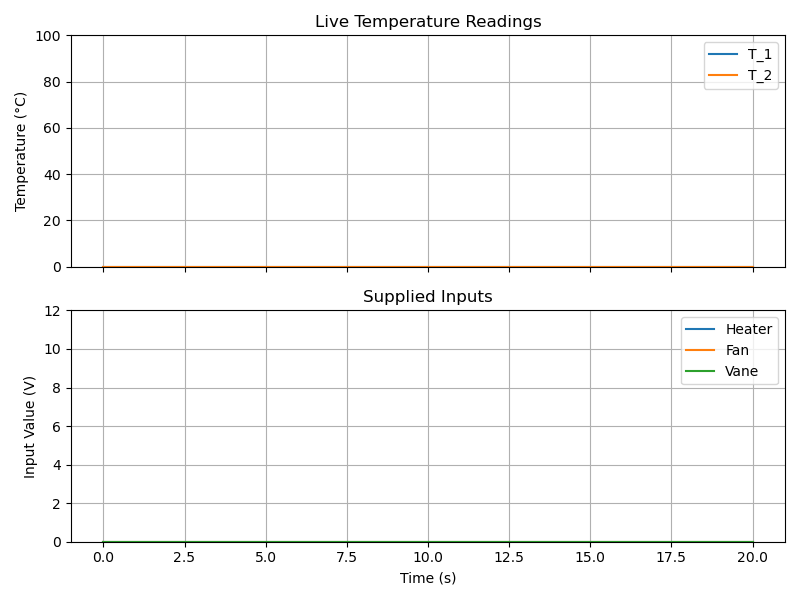

In [13]:
# Signal Scope Cell
ani = None # Global variable to hold the animation object
plt.close("all") # Close all previous figures to avoid overlap

window_length = 20 # seconds
dt = 0.1 # seconds
def run_T_scope():
    global ani
    if ani is not None:
        ani.event_source.stop()  # Stop the existing animation

    plt.close("all")  # Close all previous figures to avoid overlap
    # Create two subplots: one for temperatures, one for inputs
    fig, (ax_temp, ax_input) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Temperature lines
    # Temperature lines
    line1, = ax_temp.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='T_1')
    line2, = ax_temp.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='T_2')
    # line_model, = ax_temp.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='T_model', linestyle='--')
    
    # Input lines
    line3, = ax_input.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='Heater')
    line4, = ax_input.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='Fan')
    line5, = ax_input.plot(np.linspace(0, window_length, int(window_length / dt)), np.zeros(int(window_length / dt)), label='Vane')
    
    # Plot settings, feel free to change these how you see fit
    #Temperature plot settings
    ax_temp.legend()
    ax_temp.set_ylim(0, 100)
    ax_temp.set_title("Live Temperature Readings")
    ax_temp.set_ylabel("Temperature (°C)")
    ax_temp.grid(True)

    #Input signal plot settings
    ax_input.legend()
    ax_input.set_ylim(0, 12)
    ax_input.set_title("Supplied Inputs")
    ax_input.set_xlabel("Time (s)")
    ax_input.set_ylabel("Input Value (V)")
    ax_input.grid(True)

    # Use the AnimateScope signature
    state = AnimateScope([line1, line2], [line3, line4, line5], ax_temp, ax_input, window_length=window_length, dt=dt, plant=plant, plant_model=None)
    ani = animation.FuncAnimation(fig,
                                 state.animate,
                                 init_func=state.init_plot,
                                 interval=100,
                                 blit=True,
                                 save_count=0)

    plt.tight_layout()
    plt.show()

run_T_scope()

### Now change the inputs, does the model react properly?

In [14]:
# HeatSlider = widgets.FloatSlider(value = 0.0, min = 0.0, max = 10.0, step = 0.01, description='Heater Power')
# FanSlider = widgets.FloatSlider(value = 0.0, min = 0.0, max = 10.0, step = 0.01, description='Fan Power')
# VaneSlider = widgets.FloatSlider(value = 0.0, min = 0.0, max = 10.0, step = 0.01, description='Vane Rotation')

# widgets.interact(plant.write_heater, heater_input=HeatSlider);
# widgets.interact(plant.write_fan, fan_input=FanSlider);
# widgets.interact(plant.write_vane, vane_input=VaneSlider);

### Control: Build your own controller

In [15]:
# Run control loop in a separate thread to keep widgets responsive
T_ref = 40.0  # Desired temperature reference
control_duration = 150  # Control loop duration in seconds
dt = 0.1  # Control loop time step in seconds
data_collector_ctrl = CollectMeasurementData(plant, fs=1/dt, Exp_length_minutes=control_duration/60, display_button=False)

def controller_PID(T_current, T_ref = T_ref, dt = dt, int_error=0):
        # Write your own control loop here, this function is 
        
        error = T_ref - T_current
        # Implement a simple proportional controller as an example
        Kp = 3  # Proportional gain, you can tune this
        KI = 1e-5 # Integral gain, you can tune this
        heater_power = KI * int_error + Kp * error
        fan_power = -0.5 * error  # Example: fan power is proportional to heater power
        ##
        
        # heater_power = 0
        # fan_power = 0
        vane_rotation = 0
        int_error += error * dt
        # Ensure the powers remain within valid range [0, 10]
        unsaturated_output_powers = [heater_power, fan_power, vane_rotation]
        output_powers = [max(0, min(10, u_in)) for u_in in unsaturated_output_powers]
        return output_powers[0], output_powers[1], output_powers[2], int_error


## DO NOT TOUCH THIS PART OF THIS CELL
thermal_control_loop = ThermalControlApparatus().control_loop
controller_thread = threading.Thread(target=thermal_control_loop, args=(plant, controller_PID, control_duration, dt))
data_collector_ctrl.start()
controller_thread.start()


Data logging to: Z:\Exp_Data_Out\ExperimentData_20260416_185127.csv


Button(button_style='danger', description='Stop Controller', style=ButtonStyle())

### After you're done experimenting, always run the cool-down command cell before exiting the environment

In [ ]:
# # cool down the system when done experimenting
# plant.cooling_down()
# plant.stop()

'Measurement completed after 150.101 seconds'